## PySTAMPAS with subtracted signal

The goal of this notebook is to test PySTAMPAS on the data with and without signal subtraction for the loudest BBh signal. Here we just consider E1 data around that signal.

In [59]:
from gwpy.timeseries import TimeSeries
from pystampas.params import read_yaml
from pystampas.ftmap import FTmap
from pystampas.algorithms.burstegard import burstegard
import numpy as np
from scipy.interpolate import interp1d
import glob
import matplotlib.pyplot as plt
import pickle
import sys
sys.path.append('../src/') # Path to folder where the likelihood model is defined

In [60]:
injections_list = np.loadtxt('../input/list_mdc1_v2.txt') # Path to injections list
i_max = np.argmax(injections_list[:,-2])
t_start = injections_list[i_max, 1]
t_end = injections_list[i_max, 2]

files = glob.glob('/home/shared/et-mdc-frame-files/mdc1/v2/data/E1/*.gwf')

In [31]:
tsd = TimeSeries.read(files, channel='E1:STRAIN', start=int(t_end-260), end=int(t_end+260))

## 1 - Original data

First we build a time-frequency map of the original data using pystampas FTmap object.

(<Figure size 1200x600 with 2 Axes>,
 <Axes: xlabel='Time [s] from 2011-10-02 19:49:55', ylabel='Frequency [Hz]'>)

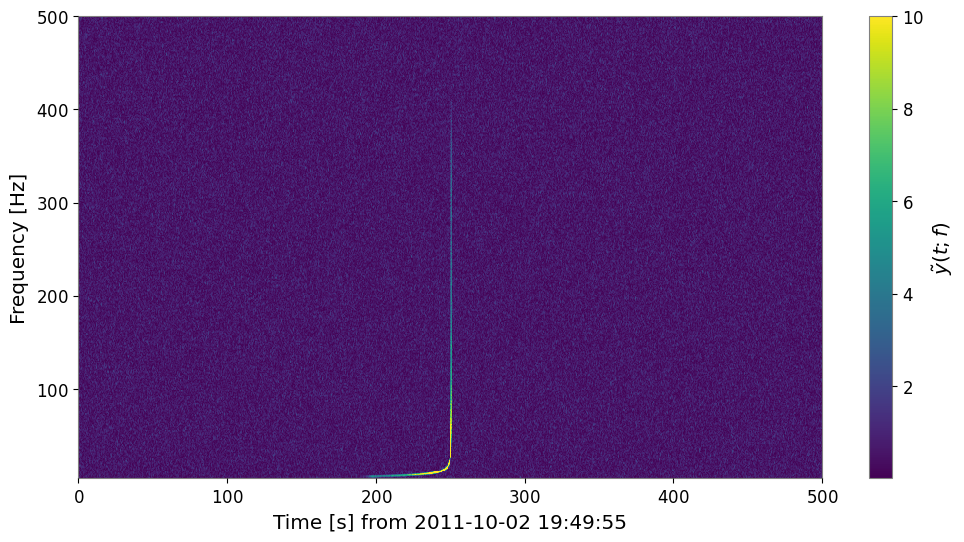

In [32]:
ftmap = FTmap.build(tsd, t_end - 250, t_end + 250, 1, 1, 4, 500, psd_method='fullMedian')
ftmap.abs().plot(vmax=10)

Next we run a clustering (i.e pattern recognition) algorithm on this FTmap to look for excess-power clusters (i.e candidate GW events).

2025-07-15 11:53:01.293 | INFO     | pystampas.algorithms.burstegard:burstegard:121 - Run burstegard over 1088 seeds...
100%|████████████████████████████████████| 1088/1088 [00:00<00:00, 18302.96it/s]
2025-07-15 11:53:01.356 | DEBUG    | pystampas.algorithms.burstegard:burstegard:162 - Number of pixels in largest cluster: 922


1 cluster(s) found


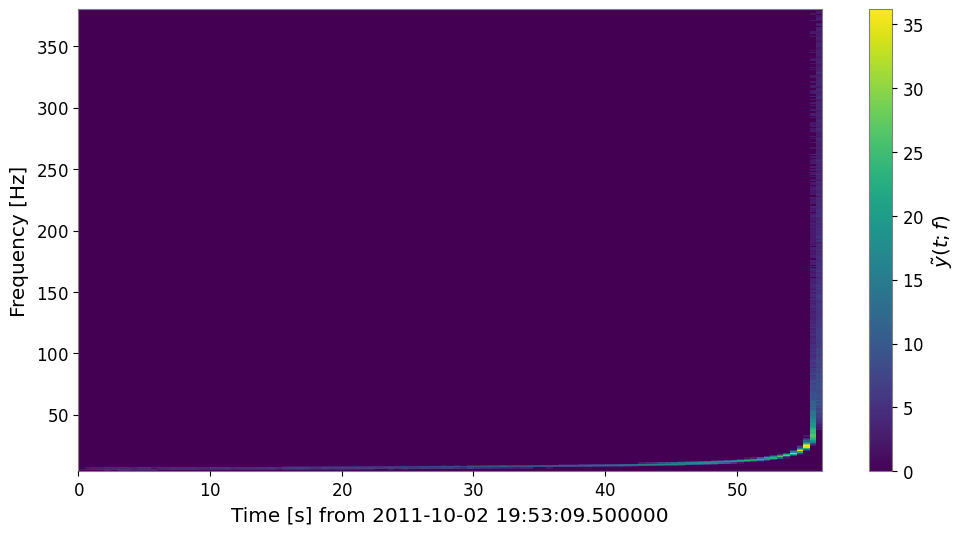

In [57]:
clusters = burstegard([ftmap], 2, 2, 2, 50)
print(str(len(clusters)) + " cluster(s) found")
if len(clusters) > 0:
    cluster_ftmap = clusters[0].reconstruct_ftmap(ftmap).abs().plot()


With the original dataset, the algorithm finds one big cluster corresponding to the loudest BBH in the dataset.

## Data subtraction

Now we do the same with subtracted data. First we read the "likelihood" model file with the maximized parameters:

In [61]:
with open('../output_1001620398-1001620461/model_optimized_1001620398-1001620461.pkl', 'rb') as f: # Path to pickle file containing the model
    model = pickle.load(f)

Then we reconstruct the BBH waveform from the maximized parameters:

In [58]:
_, reconstructed_signal = model.reconstruct_signal()

Waveform approximate duration: 55.1s
Segment duration: 64.0s


Finally we subtract the reconstructed signal from the original data and build the resulting FTmap:

In [47]:
def subtract_signal(original_signal, reconstructed_signal_tdomain):
    """
    Subtract the reconstructed signal from the original data in the time domain.

    Parameters
    ----------
    original_data : dict
        Dictionary containing the original TimeSeries for each detector.
    reconstructed_signal_tdomain : dict
        Dictionary containing the reconstructed TimeSeries for each detector.

    Returns
    -------
    subtracted_signal_tdomain : dict 
        Dictionary containing the residual TimeSeries for each detector.
    """

    # Interpolate reconstructed signal with time stamps of the original data
    t1 = original_signal.get_sample_times().data
    t2 = reconstructed_signal_tdomain.get_sample_times().data
    
    h1 = original_signal.data
    h2 = reconstructed_signal_tdomain.data
    
    h_of_t = interp1d(t2, h2, bounds_error=False, fill_value=0)
    h_new = h_of_t(t1)

    residual = TimeSeries(h1 - h_new, times=t1)
    subtracted_signal_tdomain = residual.to_pycbc()

    return subtracted_signal_tdomain

residual = subtract_signal(tsd.to_pycbc(), reconstructed_signal['E1'])

(<Figure size 1200x600 with 2 Axes>,
 <Axes: xlabel='Time [s] from 2011-10-02 19:49:55', ylabel='Frequency [Hz]'>)

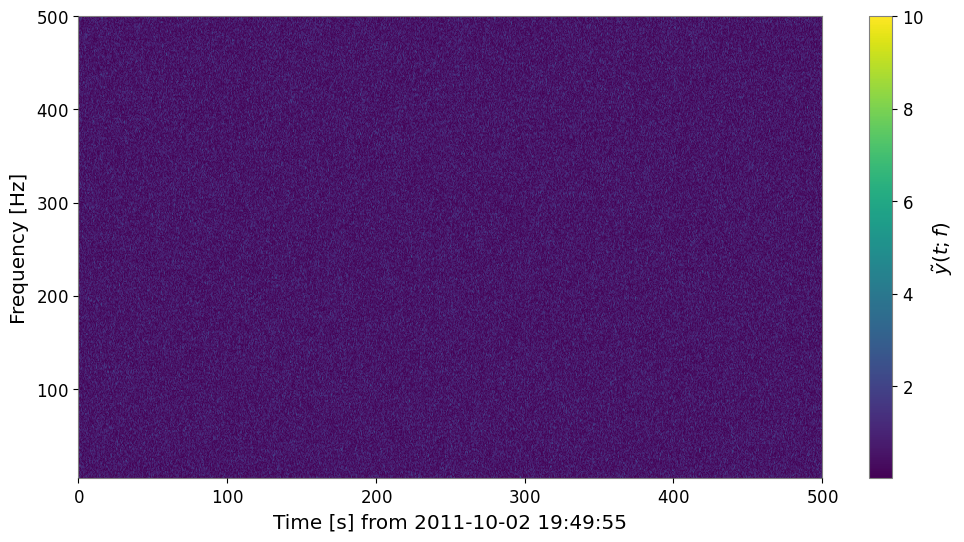

In [49]:
tsd_residual = TimeSeries.from_pycbc(residual)
ftmap_residual = FTmap.build(tsd_residual, t_end - 250, t_end + 250, 1, 1, 4, 500, psd_method='fullMedian')
ftmap_residual.abs().plot(vmax=10)

(200.0, 300.0)

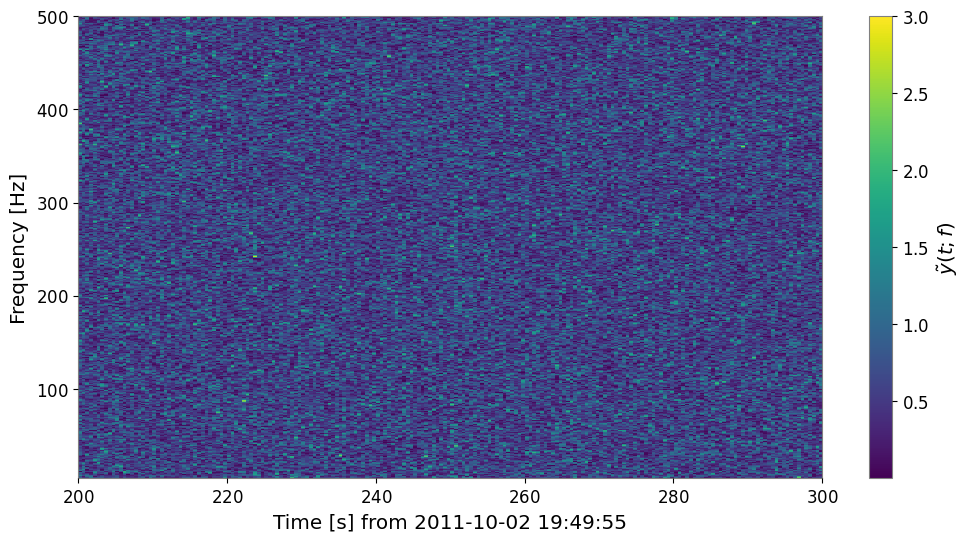

In [51]:
fig, ax = ftmap_residual.abs().plot(vmax=3)
ax.set_xlim(200,300)

In [56]:
clusters = burstegard([ftmap_residual], 2, 2, 2, 50)
print(str(len(clusters)) + " cluster(s) found")
if len(clusters) > 0:
    cluster_ftmap = clusters[0].reconstruct_ftmap(ftmap).abs().plot()

2025-07-15 11:49:49.791 | INFO     | pystampas.algorithms.burstegard:burstegard:121 - Run burstegard over 190 seeds...
100%|██████████████████████████████████████| 190/190 [00:00<00:00, 24449.83it/s]
2025-07-15 11:49:49.802 | DEBUG    | pystampas.algorithms.burstegard:burstegard:162 - Number of pixels in largest cluster: 3


0 cluster(s) found
